| Task                      | Sub-task                                                                       | Comments (Status/Findings)    | Individual Responsible       |
|:------------------------- |:------------------------------------------------------------------------------ |:----------------------------- |:---------------------------- |
| Data Preprocessing        | Scaling and Resizing                                                           | Done                          | Riya Kalpeshkumar Shah       |
|                           | Image Augmentation                                                             | Done                          | Riya Kalpeshkumar Shah       |
|                           | Train and test data handled correctly                                          | Done                          | Riya Kalpeshkumar Shah       |
|                           | Gaussian Blur, Histogram Equalization, Intensity thresholds                    | Not Done / N.A.               | Riya Kalpeshkumar Shah       |
| Model Trained (Model 1)   | Training Time?                                                                 | To be added                   | Mueez Ur Rehman Amjad        |
|                           | AUC and Confusion Matrix Computed                                              | To be added                   | Mueez Ur Rehman Amjad        |
|                           | Overfitting/Underfitting checked and handled                                   | To be added                   | Mueez Ur Rehman Amjad        |
| Data-Centric AI (Model 1) | Interpretability Implemented                                                   | SHAP / LIME / Not Implemented | Mueez Ur Rehman Amjad        |
|                           | 1st Round of Tuning                                                            | Issue Faced / Fix Applied     | Mueez Ur Rehman Amjad        |
|                           | 2nd Round of Tuning                                                            | Issue Faced / Fix Applied     | Mueez Ur Rehman Amjad        |
| Model Trained (Model 2)   | Training Time?                                                                 | 27.83 minutes                 | Advait Manishkumar Pandit    |
|                           | AUC and Confusion Matrix Computed                                              | AUC = 0.9903, Confusion Matrix Done                   | Advait Manishkumar Pandit    |
|                           | Overfitting/Underfitting checked and handled                                   | Done, Training vs. Validation curves show no severe overfitting/underfitting                   | Advait Manishkumar Pandit    |
| Data-Centric AI (Model 2) | Interpretability Implemented                                                   | SHAP / LIME / Not Implemented | Om Kiranbhai Patel           |
|                           | 1st Round of Tuning                                                            | Issue Faced / Fix Applied     | Om Kiranbhai Patel           |
|                           | 2nd Round of Tuning                                                            | Issue Faced / Fix Applied     | Om Kiranbhai Patel           |
| Model Trained (Model 3)   | Training Time?                                                                 | To be added                   | Arish Panjwani               |
|                           | AUC and Confusion Matrix Computed                                              | To be added                   | Arish Panjwani               |
|                           | Overfitting/Underfitting checked and handled                                   | To be added                   | Arish Panjwani               |
| Data-Centric AI (Model 3) | Interpretability Implemented                                                   | SHAP / LIME / Not Implemented | Kanika                  |
|                           | 1st Round of Tuning                                                            | Issue Faced / Fix Applied     | Kanika                |
|                           | 2nd Round of Tuning                                                            | Issue Faced / Fix Applied     | Kanika                 |
| Model Trained (Model 4)   | Training Time?                                                                 | To be added                   | Tanzima Mohammadyasin Shaikh |
|                           | AUC and Confusion Matrix Computed                                              | To be added                   | Tanzima Mohammadyasin Shaikh |
|                           | Overfitting/Underfitting checked and handled                                   | To be added                   | Tanzima Mohammadyasin Shaikh |
| Data-Centric AI (Model 4) | Interpretability Implemented                                                   | SHAP / LIME / Not Implemented | Nischal Pradhan              |
|                           | 1st Round of Tuning                                                            | Issue Faced / Fix Applied     | Nischal Pradhan              |
|                           | 2nd Round of Tuning                                                            | Issue Faced / Fix Applied     | Nischal Pradhan              |
| Model Trained (Model 5)   | Training Time?                                                                 | To be added                   | Ashish Lama                  |
|                           | AUC and Confusion Matrix Computed                                              | To be added                   | Ashish Lama                  |
|                           | Overfitting/Underfitting checked and handled                                   | To be added                   | Ashish Lama                  |
| Data-Centric AI (Model 5) | Interpretability Implemented                                                   | SHAP / LIME / Not Implemented | Kanika                |
|                           | 1st Round of Tuning                                                            | Issue Faced / Fix Applied     | Kanika                |
|                           | 2nd Round of Tuning                                                            | Issue Faced / Fix Applied     | Kanika                |
| Final Submission          | Merge notebooks, summary table, model insights, <br> export PDF, code quality check | To be completed               | Om Kiranbhai Patel           |


# Data Preprocessing 

### Author : Riya Kalpeshkumar Shah
### Stratified sampling technique to select random sample of data

In [2]:
import json
import os
import random
from shutil import copyfile
from collections import defaultdict

# --- CONFIGURATION ---
json_file = 'photos.json'
image_folder = 'photos/'
output_folder = 'stratified_data_processed/'
sample_fraction = 0.1   # ← Take 10% from each class (adjust as needed)

# Create output directory
os.makedirs(output_folder, exist_ok=True)

# Load JSON data
data = []
with open(json_file, 'r') as f:
    for line in f:
        data.append(json.loads(line))

# Group photos by label
label_to_items = defaultdict(list)
for item in data:
    label_to_items[item['label']].append(item)

# Print original distribution
original_counts = {label: len(items) for label, items in label_to_items.items()}
print("Original label distribution:", original_counts)

# Stratified sampling
stratified_data = []
for label, items in label_to_items.items():
    k = max(1, int(len(items) * sample_fraction))  # ensure at least 1 item
    sampled = random.sample(items, k=k)
    stratified_data.extend(sampled)
    print(f"{label}: sampled {k} out of {len(items)}")

# Shuffle final dataset
random.shuffle(stratified_data)

# Copy sampled images to stratified folders
for item in stratified_data:
    photo_id = item['photo_id']
    label = item['label']
    src = os.path.join(image_folder, f"{photo_id}.jpg")
    label_folder = os.path.join(output_folder, label)
    dst = os.path.join(label_folder, f"{photo_id}.jpg")

    os.makedirs(label_folder, exist_ok=True)

    if os.path.exists(src):
        copyfile(src, dst)
    else:
        print(f"Warning: Image not found: {src}")

print(f"Total images after stratified sampling: {len(stratified_data)}")


Original label distribution: {'inside': 56031, 'outside': 18569, 'drink': 15670, 'food': 108152, 'menu': 1678}
inside: sampled 5603 out of 56031
outside: sampled 1856 out of 18569
drink: sampled 1567 out of 15670
food: sampled 10815 out of 108152
menu: sampled 167 out of 1678
Total images after stratified sampling: 20008


### Data augmentation in outside, menu and food

In [3]:
import json
import os
import numpy as np
from PIL import Image
from shutil import copyfile
from collections import defaultdict
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Original Directory Organization
json_file = 'photos.json'
image_folder = 'photos/'
output_folder = 'preprocessed_data/'

os.makedirs(output_folder, exist_ok=True)

# Read JSON data
data = []
with open(json_file, 'r') as f:
    for line in f:
        data.append(json.loads(line))

# Create label mapping and counts
label_map = {item['photo_id']: item['label'] for item in data}
label_counts = defaultdict(int)

for item in data:
    label_counts[item['label']] += 1

print("Original Label Distribution:", dict(label_counts))

# 2. Create Initial Directory Structure
for label in label_counts:
    os.makedirs(os.path.join(output_folder, label), exist_ok=True)

# 3. Copy Images to Class Folders with Progress Tracking
print("\nCopying images to class folders...")
copied_files = 0
missing_files = 0

for item in tqdm(data, desc="Organizing images"):
    photo_id = item['photo_id']
    label = item['label']

    source_path = None
    for ext in ['.jpg', '.jpeg', '.png']:
        temp_path = os.path.join(image_folder, photo_id + ext)
        if os.path.exists(temp_path):
            source_path = temp_path
            break

    if source_path:
        dest_path = os.path.join(output_folder, label, os.path.basename(source_path))
        copyfile(source_path, dest_path)
        copied_files += 1
    else:
        missing_files += 1

print(f"\nCopied {copied_files} images, {missing_files} files missing")

# 4. Class Balancing Implementation
print("\nBalancing classes with selective augmentation...")

# Set target: match 25% of majority class
majority_count = max(label_counts.values())
target_count = int(majority_count * 0.25)

# Define which classes need augmentation
classes_to_augment = {'outside', 'menu', 'drink'}

# Set up augmentation
augmentation_config = {
    'rotation_range': 20,
    'width_shift_range': 0.2,
    'height_shift_range': 0.2,
    'shear_range': 0.2,
    'zoom_range': 0.2,
    'horizontal_flip': True,
    'fill_mode': 'nearest'
}
augmenter = ImageDataGenerator(**augmentation_config)

# 5. Balance Each Class
balanced_folder = 'balanced_data'
os.makedirs(balanced_folder, exist_ok=True)

for label in label_counts:
    os.makedirs(os.path.join(balanced_folder, label), exist_ok=True)

    class_dir = os.path.join(output_folder, label)
    image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    current_count = len(image_files)
    final_target = min(target_count, current_count) if label not in classes_to_augment else target_count

    if current_count >= final_target:
        for file in tqdm(image_files[:final_target], desc=f"Copying {label}"):
            src = os.path.join(class_dir, file)
            dst = os.path.join(balanced_folder, label, file)
            copyfile(src, dst)
    else:
        print(f"\nBalancing {label}: Current={current_count}, Target={final_target}")
        copies_needed = final_target - current_count

        # Copy originals
        for file in image_files:
            src = os.path.join(class_dir, file)
            dst = os.path.join(balanced_folder, label, file)
            copyfile(src, dst)

        if label in classes_to_augment:
            augment_per_image = max(1, copies_needed // current_count)
            extra_needed = copies_needed - (augment_per_image * current_count)

            for idx, file in enumerate(tqdm(image_files, desc=f"Augmenting {label}")):
                src_path = os.path.join(class_dir, file)
                try:
                    img = Image.open(src_path).convert('RGB')
                    img_array = np.array(img)

                    for i in range(augment_per_image):
                        augmented = augmenter.random_transform(img_array)
                        aug_file = f"{os.path.splitext(file)[0]}_aug{i}.jpg"
                        Image.fromarray(augmented).save(os.path.join(balanced_folder, label, aug_file), quality=95)

                    # Add a few more to reach target
                    if idx < extra_needed:
                        augmented = augmenter.random_transform(img_array)
                        aug_file = f"{os.path.splitext(file)[0]}_extra_aug.jpg"
                        Image.fromarray(augmented).save(os.path.join(balanced_folder, label, aug_file), quality=95)

                except Exception as e:
                    print(f"Error processing {file}: {str(e)}")

# 6. Verify Final Distribution
print("\nFinal Balanced Distribution:")
balanced_counts = {}
for label in label_counts:
    class_dir = os.path.join(balanced_folder, label)
    balanced_counts[label] = len([f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"{label}: {balanced_counts[label]}")

print("\nBalancing complete! Final dataset in:", balanced_folder)



Original Label Distribution: {'inside': 56031, 'outside': 18569, 'drink': 15670, 'food': 108152, 'menu': 1678}

Copying images to class folders...


Organizing images: 100%|██████████| 200100/200100 [08:59<00:00, 370.56it/s]



Copied 200100 images, 0 files missing

Balancing classes with selective augmentation...


Copying inside: 100%|██████████| 27038/27038 [21:39<00:00, 20.81it/s]   



Balancing outside: Current=18569, Target=27038


...


Balancing drink: Current=15670, Target=27038


Copying food: 100%|██████████| 27038/27038 [04:34<00:00, 98.52it/s] 



Balancing menu: Current=1678, Target=27038


Augmenting menu: 100%|██████████| 1678/1678 [42:11<00:00,  1.51s/it]    



Final Balanced Distribution:
inside: 27038
outside: 37138
drink: 31340
food: 27038
menu: 27038

Balancing complete! Final dataset in: balanced_data


In [ ]:
#=====================>>> This point

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm
import json

# Configuration
input_json = 'photos.json'
balanced_data_dir = 'balanced_data/'  # Output from imbalance correction
output_dir = 'final_processed_data/'  # For processed images
target_size = (224, 224)

# Create output directory
os.makedirs(output_dir, exist_ok=True)

# Load JSON data
with open(input_json, 'r') as f:
    data = [json.loads(line) for line in f]

# Initialize tracking
processed_images = {}
failed_images = []

def preprocess_image(image_path, target_size=(224, 224)):
    """Enhanced preprocessing with better error handling"""
    # 1. Gaussian Blur
    img = cv2.GaussianBlur(img, (5, 5), 0)
    
    # 2. Histogram Equalization (for grayscale or each channel)
    img_yuv = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img_yuv[:, :, 0] = cv2.equalizeHist(img_yuv[:, :, 0])
    img = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2RGB)
    
    # 3. Intensity Thresholding (optional, adjust thresholds as needed)
    _, img_thresh = cv2.threshold(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), 30, 255, cv2.THRESH_TOZERO)
    img = cv2.cvtColor(img_thresh, cv2.COLOR_GRAY2RGB)
    try:
        # Try OpenCV first
        img = cv2.imread(image_path)
        if img is None:
            # Fallback to PIL if OpenCV fails
            try:
                img = np.array(Image.open(image_path).convert('RGB'))
                img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            except Exception as e:
                print(f"Failed to load {image_path} with PIL: {str(e)}")
                return None
        
        # Convert to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Resize with aspect ratio preservation
        h, w = img.shape[:2]
        scale = min(target_size[0]/h, target_size[1]/w)
        new_h, new_w = int(h * scale), int(w * scale)
        img = cv2.resize(img, (new_w, new_h))
        
        # Pad if needed
        if new_h != target_size[0] or new_w != target_size[1]:
            delta_h = target_size[0] - new_h
            delta_w = target_size[1] - new_w
            top, bottom = delta_h//2, delta_h-(delta_h//2)
            left, right = delta_w//2, delta_w-(delta_w//2)
            img = cv2.copyMakeBorder(img, top, bottom, left, right, 
                                   cv2.BORDER_CONSTANT, value=[0, 0, 0])
        
        # Normalize and return
        return img.astype(np.float32) / 255.0
    
    except Exception as e:
        print(f"Error processing {image_path}: {str(e)}")
        return None

# Process all images
print(f"\nProcessing images from {balanced_data_dir}...")
for item in tqdm(data, desc="Processing Images"):
    photo_id = item['photo_id']
    label = item['label']
    
    # Find the image file (check multiple extensions)
    image_path = None
    for ext in ['.jpg', '.jpeg', '.png']:
        possible_path = os.path.join(balanced_data_dir, label, f"{photo_id}{ext}")
        if os.path.exists(possible_path):
            image_path = possible_path
            break
    
    if not image_path:
        failed_images.append(photo_id)
        continue
    
    # Preprocess the image
    processed_img = preprocess_image(image_path, target_size)
    
    if processed_img is not None:
        # Prepare output directory
        label_dir = os.path.join(output_dir, label)
        os.makedirs(label_dir, exist_ok=True)
        
        # Save processed image
        output_path = os.path.join(label_dir, f"{photo_id}.jpg")
        cv2.imwrite(
            output_path,
            cv2.cvtColor((processed_img * 255).astype(np.uint8), cv2.COLOR_RGB2BGR),
            [int(cv2.IMWRITE_JPEG_QUALITY), 95]  # Save with 95% quality
        )
        
        # Store metadata
        processed_images[photo_id] = {
            'path': output_path,
            'label': label,
            'business_id': item['business_id'],
            'caption': item['caption']
        }

# Final report
print(f"\nProcessing complete!")
print(f"Successfully processed: {len(processed_images)} images")
print(f"Failed to process: {len(failed_images)} images")

if failed_images:
    print("\nFirst 10 failed images:")
    for pid in failed_images[:10]:
        print(f"- {pid}")

# Save processing log
with open(os.path.join(output_dir, 'processing_log.json'), 'w') as f:
    json.dump({
        'processed': len(processed_images),
        'failed': len(failed_images),
        'failed_samples': failed_images,
        'class_distribution': {
            label: len([v for v in processed_images.values() if v['label'] == label])
            for label in set(item['label'] for item in data)
        }
    }, f, indent=2)

print(f"\nFinal processed data saved to: {output_dir}")


Processing images from balanced_data/...


Processing Images:   5%|▌         | 10813/200100 [01:42<35:50, 88.02it/s] 

Failed to load balanced_data/food\bf3ymV0YgP7B6rEoriaU2w.jpg with PIL: cannot identify image file 'balanced_data/food\\bf3ymV0YgP7B6rEoriaU2w.jpg'


Processing Images:   7%|▋         | 13782/200100 [02:11<35:48, 86.72it/s] 

Failed to load balanced_data/food\9X4YPM8nYFjf7hY8xUdc6Q.jpg with PIL: cannot identify image file 'balanced_data/food\\9X4YPM8nYFjf7hY8xUdc6Q.jpg'


...

Failed to load balanced_data/food\ARwqGQZaT0p-XpYYjMXgQg.jpg with PIL: cannot identify image file 'balanced_data/food\\ARwqGQZaT0p-XpYYjMXgQg.jpg'


Processing Images:  97%|█████████▋| 194262/200100 [35:37<01:14, 77.91it/s]

Failed to load balanced_data/food\9jBH61ndIcsheo6FtIHArA.jpg with PIL: cannot identify image file 'balanced_data/food\\9jBH61ndIcsheo6FtIHArA.jpg'


Processing Images: 100%|██████████| 200100/200100 [36:46<00:00, 90.67it/s] 



Processing complete!
Successfully processed: 89964 images
Failed to process: 110107 images

First 10 failed images:
- zsvj7vloL4L5jhYyPIuVwg
- pve7D6NUrafHW3EAORubyw
- H52Er-uBg6rNrHcReWTD2w
- wZ29mUm6nKz566j17OBadw
- QRUgAISgYLQJ9SK2yOwomw
- mcjlyGuLFJ0t4vDixycCSg
- yED5k8-aiPcgiUKoPRfJgg
- Le9rMdT8YFlvqr431LctIQ
- RBBVVDG3t4lTTyl_vW2W3A
- dxIzVOEowFFsg2RmgFJZdQ

Final processed data saved to: final_processed_data/


In [5]:
import os
import json
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import shutil

def create_train_val_test_splits(processed_images, output_folder='final_processed_data'):
    """
    Creates train/val/test splits from processed images and organizes them into directories
    Args:
        processed_images: Dictionary containing processed image metadata
        output_folder: Root directory where processed images are stored
    """
    
    # 1. Prepare the data for splitting
    photo_ids = list(processed_images.keys())
    labels = [processed_images[pid]['label'] for pid in photo_ids]
    
    # 2. Create stratified splits (80/10/10)
    print("\nCreating dataset splits...")
    
    # First split: 80% train, 20% temp (val+test)
    train_ids, temp_ids, train_labels, temp_labels = train_test_split(
        photo_ids, labels, test_size=0.2, random_state=42, stratify=labels)
    
    # Second split: 10% val, 10% test from the temp
    val_ids, test_ids, val_labels, test_labels = train_test_split(
        temp_ids, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)
    
    print(f"Train samples: {len(train_ids)}")
    print(f"Validation samples: {len(val_ids)}")
    print(f"Test samples: {len(test_ids)}")
    
    # 3. Create directory structure
    print("\nCreating directory structure...")
    split_dirs = ['train', 'val', 'test']
    all_labels = set(labels)
    
    for split in split_dirs:
        for label in all_labels:
            os.makedirs(os.path.join(output_folder, split, label), exist_ok=True)
    
    # 4. Enhanced file moving with progress tracking and error handling
    def organize_files(id_list, split_name):
        moved_files = 0
        missing_files = 0
        errors = 0
        
        for pid in tqdm(id_list, desc=f"Organizing {split_name} set"):
            label = processed_images[pid]['label']
            src_path = processed_images[pid]['processed_path']
            
            if not os.path.exists(src_path):
                missing_files += 1
                continue
            
            dest_path = os.path.join(
                output_folder,
                split_name,
                label,
                os.path.basename(src_path)
            )
            
            try:
                shutil.move(src_path, dest_path)
                moved_files += 1
                # Update the path in metadata
                processed_images[pid]['processed_path'] = dest_path
            except Exception as e:
                errors += 1
                print(f"Error moving {src_path}: {str(e)}")
        
        print(f"\n{split_name.capitalize()} set:")
        print(f"Successfully moved: {moved_files}")
        print(f"Missing files: {missing_files}")
        print(f"Errors: {errors}")
    
    # 5. Organize files into their respective splits
    organize_files(train_ids, 'train')
    organize_files(val_ids, 'val')
    organize_files(test_ids, 'test')
    
    # 6. Save split information for reference
    split_info = {
        'train': train_ids,
        'val': val_ids,
        'test': test_ids
    }
    
    with open(os.path.join(output_folder, 'split_info.json'), 'w') as f:
        json.dump(split_info, f, indent=2)
    
    print("\nDataset organization complete!")
    print(f"Final structure created in: {output_folder}")
    
    return processed_images

# Example usage after preprocessing:
if __name__ == "__main__":
    # Assuming you have processed_images from previous steps
    with open('photos.json', 'r') as f:
        data = [json.loads(line) for line in f]
    
    # Create processed_images dictionary (from previous steps)
    processed_images = {}
    for item in data:
        photo_id = item['photo_id']
        processed_images[photo_id] = {
            'label': item['label'],
            'business_id': item['business_id'],
            'caption': item['caption'],
            'processed_path': os.path.join('final_processed_data', item['label'], f"{photo_id}.jpg")
        }
    
    # Create the splits
    processed_images = create_train_val_test_splits(processed_images)


Creating dataset splits...
Train samples: 160078
Validation samples: 20010
Test samples: 20010

Creating directory structure...


Organizing train set: 100%|██████████| 160078/160078 [02:13<00:00, 1200.86it/s]



Train set:
Successfully moved: 72017
Missing files: 88061
Errors: 0


Organizing val set: 100%|██████████| 20010/20010 [00:28<00:00, 700.57it/s] 



Val set:
Successfully moved: 8964
Missing files: 11046
Errors: 0


Organizing test set: 100%|██████████| 20010/20010 [00:27<00:00, 737.63it/s] 



Test set:
Successfully moved: 8983
Missing files: 11027
Errors: 0

Dataset organization complete!
Final structure created in: final_processed_data


In [6]:
#Creating MetaData Files
import pandas as pd
import os
from tqdm import tqdm

def create_enhanced_metadata(processed_images, output_folder='final_processed_data'):
    """
    Creates comprehensive metadata files for train/val/test splits with additional features
    Args:
        processed_images: Dictionary containing all processed image metadata
        output_folder: Root directory of processed data
    """
    
    # 1. Load split information if available
    split_info_path = os.path.join(output_folder, 'split_info.json')
    if os.path.exists(split_info_path):
        with open(split_info_path, 'r') as f:
            split_info = json.load(f)
        train_ids = split_info['train']
        val_ids = split_info['val']
        test_ids = split_info['test']
    else:
        raise FileNotFoundError("Split information not found. Run create_train_val_test_splits() first.")
    
    # 2. Enhanced metadata creation with progress tracking
    def generate_metadata(id_list, split_name):
        metadata = []
        missing_files = 0
        
        for pid in tqdm(id_list, desc=f"Creating {split_name} metadata"):
            if pid not in processed_images:
                missing_files += 1
                continue
                
            img_data = processed_images[pid]
            
            # Check if file actually exists
            file_path = os.path.join(output_folder, split_name, img_data['label'], f"{pid}.jpg")
            if not os.path.exists(file_path):
                # Check for alternate extensions
                found = False
                for ext in ['.jpg', '.jpeg', '.png']:
                    alt_path = os.path.join(output_folder, split_name, img_data['label'], f"{pid}{ext}")
                    if os.path.exists(alt_path):
                        file_path = alt_path
                        found = True
                        break
                
                if not found:
                    missing_files += 1
                    continue
            
            # Create relative path for portability
            rel_path = os.path.relpath(file_path, output_folder)
            
            metadata.append({
                'photo_id': pid,
                'path': rel_path.replace("\\", "/"),  # Standardize path separators
                'absolute_path': os.path.abspath(file_path),
                'label': img_data['label'],
                'business_id': img_data['business_id'],
                'caption': img_data['caption'],
                'split': split_name,
                'file_size': os.path.getsize(file_path),
                'modified_time': os.path.getmtime(file_path)
            })
        
        if missing_files > 0:
            print(f"Warning: {missing_files} files missing from {split_name} set")
        
        return pd.DataFrame(metadata)
    
    # 3. Generate metadata for each split
    print("\nCreating metadata files...")
    train_meta = generate_metadata(train_ids, 'train')
    val_meta = generate_metadata(val_ids, 'val')
    test_meta = generate_metadata(test_ids, 'test')
    
    # 4. Save with additional options
    meta_dir = os.path.join(output_folder, 'metadata')
    os.makedirs(meta_dir, exist_ok=True)
    
    train_meta.to_csv(
        os.path.join(meta_dir, 'train_metadata.csv'),
        index=False,
        encoding='utf-8'
    )
    val_meta.to_csv(
        os.path.join(meta_dir, 'val_metadata.csv'),
        index=False,
        encoding='utf-8'
    )
    test_meta.to_csv(
        os.path.join(meta_dir, 'test_metadata.csv'),
        index=False,
        encoding='utf-8'
    )
    
    # 5. Create combined metadata file
    combined_meta = pd.concat([train_meta, val_meta, test_meta])
    combined_meta.to_csv(
        os.path.join(meta_dir, 'combined_metadata.csv'),
        index=False,
        encoding='utf-8'
    )
    
    # 6. Save statistics
    stats = {
        'total_samples': len(combined_meta),
        'train_samples': len(train_meta),
        'val_samples': len(val_meta),
        'test_samples': len(test_meta),
        'class_distribution': combined_meta['label'].value_counts().to_dict()
    }
    
    with open(os.path.join(meta_dir, 'dataset_stats.json'), 'w') as f:
        json.dump(stats, f, indent=2)
    
    print("\nMetadata creation complete!")
    print(f"Files saved in: {meta_dir}")
    
    return {
        'train': train_meta,
        'val': val_meta,
        'test': test_meta,
        'combined': combined_meta
    }

# Example usage:
if __name__ == "__main__":
    # Assuming processed_images is available from previous steps
    metadata = create_enhanced_metadata(processed_images)


Creating metadata files...


Creating train metadata: 100%|██████████| 160078/160078 [01:29<00:00, 1782.81it/s]


Creating val metadata: 100%|██████████| 20010/20010 [00:09<00:00, 2013.23it/s]


Creating test metadata: 100%|██████████| 20010/20010 [00:10<00:00, 1836.29it/s]



Metadata creation complete!
Files saved in: final_processed_data\metadata


# Author: Advait Manishkumar Pandit
Model 2 Training

In [ ]:
import os
import random
import time
import collections
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers, Input
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1. Build Ordered Lists of ALL TRAINING IMAGE Paths & Corresponding Classes
train_dir = os.path.join('preprocessed', 'train')
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes:", class_names)

all_train_paths = []
all_train_labels = [] 
for idx, cls in enumerate(class_names):
    class_folder = os.path.join(train_dir, cls)
    filenames = sorted(os.listdir(class_folder))
    for fname in filenames:
        rel_path = os.path.join('train', cls, fname).replace("\\", "/")
        all_train_paths.append(rel_path)
        all_train_labels.append(idx)

num_total = len(all_train_paths)
print(f"Total training images available: {num_total}")

Classes: ['drink', 'food', 'inside', 'menu', 'outside']
Total training images available: 72017


In [ ]:
# 2. Stratified Sampling: Pick 20,000 Images Proportionally by Class
desired_total = 20000
# Count how many images per class
class_counts = collections.Counter(all_train_labels)
print("Original class counts:", class_counts)

# Compute desired samples per class (rounded)
samples_per_class = {}
for cls_idx, count in class_counts.items():
    proportion = count / num_total
    samples_per_class[cls_idx] = int(round(proportion * desired_total))

# Adjust rounding if sum != desired_total
current_sum = sum(samples_per_class.values())
diff = desired_total - current_sum
if diff != 0:
    # Find classes with largest residual error and adjust
    residuals = {}
    for cls_idx, count in class_counts.items():
        exact = (count / num_total) * desired_total
        residuals[cls_idx] = exact - samples_per_class[cls_idx]
    # Sort by residual descending if diff > 0, ascending if diff < 0
    sorted_classes = sorted(residuals.items(), key=lambda x: x[1], reverse=(diff > 0))
    i = 0
    while diff != 0:
        cls_to_adjust = sorted_classes[i][0]
        samples_per_class[cls_to_adjust] += 1 if diff > 0 else -1
        diff += -1 if diff > 0 else 1
        i += 1

print("Samples per class after adjustment:", samples_per_class)
assert sum(samples_per_class.values()) == desired_total

# Now perform random sampling within each class
random.seed(42)
sampled_paths = []
sampled_labels = []
for cls_idx in class_counts.keys():
    # Collect all indices of images belonging to this class
    indices = [i for i, lbl in enumerate(all_train_labels) if lbl == cls_idx]
    chosen = random.sample(indices, samples_per_class[cls_idx])
    for idx in chosen:
        sampled_paths.append(all_train_paths[idx])
        sampled_labels.append(cls_idx)

# Shuffle the sampled list once (order doesn't matter yet)
combined = list(zip(sampled_paths, sampled_labels))
random.shuffle(combined)
sampled_paths, sampled_labels = zip(*combined)
sampled_paths = list(sampled_paths)
sampled_labels = list(sampled_labels)

print(f"Total sampled images: {len(sampled_paths)} (should be {desired_total})")


Original class counts: Counter({1: 21668, 2: 21615, 4: 14855, 0: 12536, 3: 1343})
Samples per class after adjustment: {0: 3481, 1: 6018, 2: 6003, 3: 373, 4: 4125}
Total sampled images: 20000 (should be 20000)


In [ ]:
# 3. Load Metadata CSVs & Align to Sampled Image Paths
train_meta_df = pd.read_csv(os.path.join('metadata', 'train_metadata.csv'))
val_meta_df   = pd.read_csv(os.path.join('metadata', 'val_metadata.csv'))

# Ensure 'path' column exists
assert 'path' in train_meta_df.columns, "'path' missing in train_metadata.csv"
assert 'path' in val_meta_df.columns,   "'path' missing in val_metadata.csv"

# Index by 'path'
train_meta_df.set_index('path', drop=False, inplace=True)
val_meta_df.set_index('path', drop=False, inplace=True)

# Numeric metadata columns
meta_feature_cols = ['file_size', 'modified_time']

# Extract metadata for sampled train paths
missing_meta = set(sampled_paths) - set(train_meta_df.index)
assert len(missing_meta) == 0, f"Missing metadata for these sampled paths: {missing_meta}"

train_meta_ordered = train_meta_df.loc[sampled_paths, meta_feature_cols].astype('float32')
train_meta_np = train_meta_ordered.values  # shape = (20000, 2)

# For validation, we use all validation images (no sampling)
val_dir = os.path.join('preprocessed', 'val')
val_ordered_paths = []
val_labels = []
for idx, cls in enumerate(class_names):
    class_folder = os.path.join(val_dir, cls)
    filenames = sorted(os.listdir(class_folder))
    for fname in filenames:
        rel = os.path.join('val', cls, fname).replace("\\", "/")
        val_ordered_paths.append(rel)
        val_labels.append(idx)

# Extract metadata for all val paths
missing_val_meta = set(val_ordered_paths) - set(val_meta_df.index)
assert len(missing_val_meta) == 0, f"Missing metadata for these val paths: {missing_val_meta}"

val_meta_ordered = val_meta_df.loc[val_ordered_paths, meta_feature_cols].astype('float32')
val_meta_np = val_meta_ordered.values  # shape = (num_val_images, 2)

print("train_meta_np shape:", train_meta_np.shape)
print(" val_meta_np shape:", val_meta_np.shape)


train_meta_np shape: (20000, 2)
 val_meta_np shape: (8964, 2)


In [ ]:
# 4. Scale Metadata Features (Train & Val)
scaler = StandardScaler()
train_meta_np = scaler.fit_transform(train_meta_np)
val_meta_np   = scaler.transform(val_meta_np)


In [ ]:
# 5. Build tf.data.Dataset for Sampled TRAIN IMAGES & METADATA

# 5a) Convert sampled_paths to full filesystem paths
full_train_paths = [os.path.join('preprocessed', p) for p in sampled_paths]  # list of 'preprocessed/train/class/filename'

# 5b) One-hot encode sampled_labels
num_classes = len(class_names)
train_labels_onehot = tf.keras.utils.to_categorical(sampled_labels, num_classes=num_classes)

# 5c) Create tf.data.Dataset.from_tensor_slices((image_path, meta_np, label_onehot))
train_ds = tf.data.Dataset.from_tensor_slices((full_train_paths, train_meta_np, train_labels_onehot))

# 5d) Define a parsing function: load image, decode, resize, preprocess for VGG16
def load_and_preprocess(path, meta, label):
    # Read file
    image = tf.io.read_file(path)
    # Decode JPEG
    image = tf.image.decode_jpeg(image, channels=3)
    # Resize to 224×224
    image = tf.image.resize(image, [224, 224])
    # Preprocess for VGG16 (RGB→BGR, subtract ImageNet mean, etc.)
    image = tf.keras.applications.vgg16.preprocess_input(image)
    return (image, meta), label

train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# 5e) Light data augmentation on training images (after preprocessing)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def augment(inputs, label):
    img, meta = inputs
    img = data_augmentation(img, training=True)
    return (img, meta), label

train_ds = train_ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)


In [ ]:
# 5f) Shuffle + batch + prefetch
train_ds = train_ds.shuffle(buffer_size=desired_total, reshuffle_each_iteration=True)
train_ds = train_ds.batch(32)
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# 6. Build tf.data.Dataset for ALL VAL IMAGES & METADATA

# 6a) Convert val_ordered_paths to full filesystem paths
full_val_paths = [os.path.join('preprocessed', p) for p in val_ordered_paths]

# 6b) One-hot encode val_labels
val_labels_onehot = tf.keras.utils.to_categorical(val_labels, num_classes=num_classes)


In [ ]:
# 6c) Create tf.data.Dataset.from_tensor_slices((image_path, meta_np, label_onehot))
val_ds = tf.data.Dataset.from_tensor_slices((full_val_paths, val_meta_np, val_labels_onehot))
val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(32)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)


In [ ]:
# 7. Compute Class Weights for Sampled Training Set

sampled_counter = collections.Counter(sampled_labels)
print("Sampled training counts per class:", sampled_counter)
total_sampled = sum(sampled_counter.values())
class_weight = {cls: total_sampled/(num_classes * count) for cls, count in sampled_counter.items()}
print("Class weights:", class_weight)


Sampled training counts per class: Counter({1: 6018, 2: 6003, 4: 4125, 0: 3481, 3: 373})
Class weights: {1: 0.6646726487205051, 4: 0.9696969696969697, 2: 0.6663334999167083, 0: 1.1490950876185004, 3: 10.723860589812332}


In [ ]:
# 8. Build Two-Input Model (VGG16 Base + Metadata Branch)

base_model = applications.VGG16(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze VGG16 for Stage 1

img_input  = Input(shape=(224, 224, 3),       name='img_input')
meta_input = Input(shape=(train_meta_np.shape[1],), name='meta_input')

x = base_model(img_input, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Concatenate()([x, meta_input])
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=[img_input, meta_input], outputs=output)
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 img_input (InputLayer)         [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 vgg16 (Functional)             (None, 7, 7, 512)    14714688    ['img_input[0][0]']              
                                                                                                  
 global_average_pooling2d (Glob  (None, 512)         0           ['vgg16[0][0]']                  
 alAveragePooling2D)                                                                              
                                                                                              

In [ ]:
# 9. STAGE 1 TRAINING: Train Only the Dense + Metadata Head (Epochs 1–4)

start_head = time.time()
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=4,
    class_weight=class_weight
)
end_head = time.time()
head_minutes = (end_head - start_head) / 60
print(f"\nStage 1 (head-only) training time: {head_minutes:.2f} minutes\n")


Epoch 1/4
625/625 [==============================] - 195s 191ms/step - loss: 1.9750 - accuracy: 0.6198 - val_loss: 0.5216 - val_accuracy: 0.8546
Epoch 2/4
625/625 [==============================] - 183s 192ms/step - loss: 0.7383 - accuracy: 0.7679 - val_loss: 0.4001 - val_accuracy: 0.8768
Epoch 3/4
625/625 [==============================] - 185s 195ms/step - loss: 0.5599 - accuracy: 0.8070 - val_loss: 0.3904 - val_accuracy: 0.8802
Epoch 4/4
625/625 [==============================] - 197s 193ms/step - loss: 0.4730 - accuracy: 0.8280 - val_loss: 0.3458 - val_accuracy: 0.8936

Stage 1 (head-only) training time: 13.13 minutes



In [ ]:
# 10. STAGE 2 TRAINING: Unfreeze VGG block5 & Fine-Tune (Epochs 5–8)

base_model.trainable = True
for layer in base_model.layers:
    if layer.name.startswith('block5_'):
        layer.trainable = True
    else:
        layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_ft = time.time()
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=4,
    epochs=8,
    class_weight=class_weight
)
end_ft = time.time()
ft_minutes = (end_ft - start_ft) / 60
print(f"\nStage 2 (fine-tune) training time: {ft_minutes:.2f} minutes\n")

total_minutes = head_minutes + ft_minutes
print(f"Total training time (all 8 epochs): {total_minutes:.2f} minutes\n")


Epoch 5/8
625/625 [==============================] - 209s 212ms/step - loss: 0.4170 - accuracy: 0.8404 - val_loss: 0.3348 - val_accuracy: 0.8983
Epoch 6/8
625/625 [==============================] - 201s 215ms/step - loss: 0.4027 - accuracy: 0.8480 - val_loss: 0.3323 - val_accuracy: 0.8995
Epoch 7/8
625/625 [==============================] - 206s 215ms/step - loss: 0.3655 - accuracy: 0.8544 - val_loss: 0.3184 - val_accuracy: 0.9034
Epoch 8/8
625/625 [==============================] - 209s 215ms/step - loss: 0.3513 - accuracy: 0.8640 - val_loss: 0.3107 - val_accuracy: 0.9063

Stage 2 (fine-tune) training time: 14.70 minutes

Total training time (all 8 epochs): 27.83 minutes



In [ ]:
# 11. Save the Final Trained Model
save_path = 'vgg16_meta_model.h5'
model.save(save_path)
print(f"Model saved to: {save_path}\n")

Model saved to: vgg16_meta_model.h5



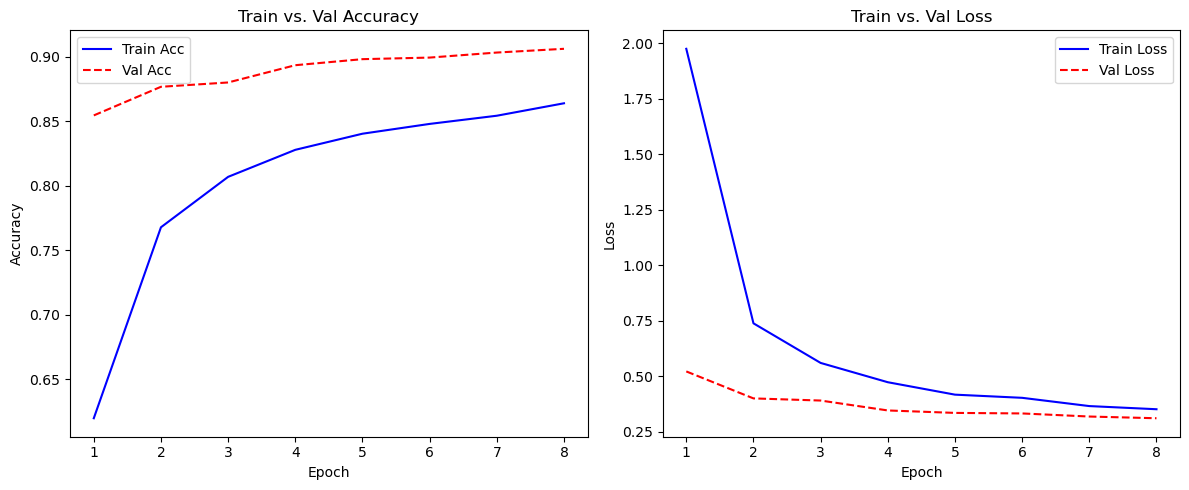

In [ ]:
# 12. Plot Training vs. Validation Accuracy & Loss (Over/Underfitting Check)

acc     = history_head.history['accuracy']      + history_finetune.history['accuracy']
valacc  = history_head.history['val_accuracy']  + history_finetune.history['val_accuracy']
loss    = history_head.history['loss']          + history_finetune.history['loss']
valloss = history_head.history['val_loss']      + history_finetune.history['val_loss']
epochs  = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc,    'b-', label='Train Acc')
plt.plot(epochs, valacc, 'r--', label='Val Acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Train vs. Val Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss,    'b-', label='Train Loss')
plt.plot(epochs, valloss, 'r--', label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Train vs. Val Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 13. Compute Confusion Matrix and Macro-Averaged AUC on Validation Set
all_preds  = []
all_labels = []
all_probs  = []

for (img_b, meta_b), label_b in val_ds:
    preds = model.predict([img_b, meta_b], verbose=0)
    all_probs.append(preds)
    all_preds.append(np.argmax(preds, axis=1))
    all_labels.append(np.argmax(label_b.numpy(), axis=1))

all_preds  = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)
all_probs  = np.concatenate(all_probs)


Confusion Matrix (Validation):
[[1447   47   53    6   14]
 [ 100 2555   33    8    2]
 [  45   60 2243   28  298]
 [   2    1    2  162    1]
 [  12    7   93   28 1717]]


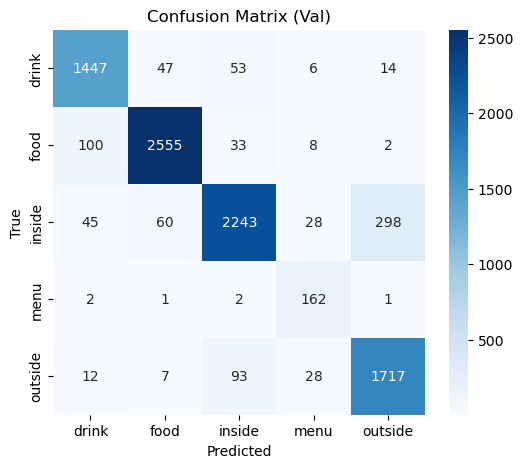

In [ ]:
# 13a) Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix (Validation):")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix (Val)')
plt.show()

In [ ]:
# 13b) Macro-Averaged AUC (One-vs-Rest)
one_hot_labels = tf.keras.utils.to_categorical(all_labels, num_classes=num_classes)
auc_scores = []
for i in range(num_classes):
    auc_i = roc_auc_score(one_hot_labels[:, i], all_probs[:, i])
    auc_scores.append(auc_i)
macro_auc = np.mean(auc_scores)
print(f"Per-class AUCs: {auc_scores}")
print(f"Macro-Averaged AUC: {macro_auc:.4f}")

Per-class AUCs: [0.9917579428835868, 0.9948007378353817, 0.9815469105429069, 0.9982506929556725, 0.9851147158303883]
Macro-Averaged AUC: 0.9903


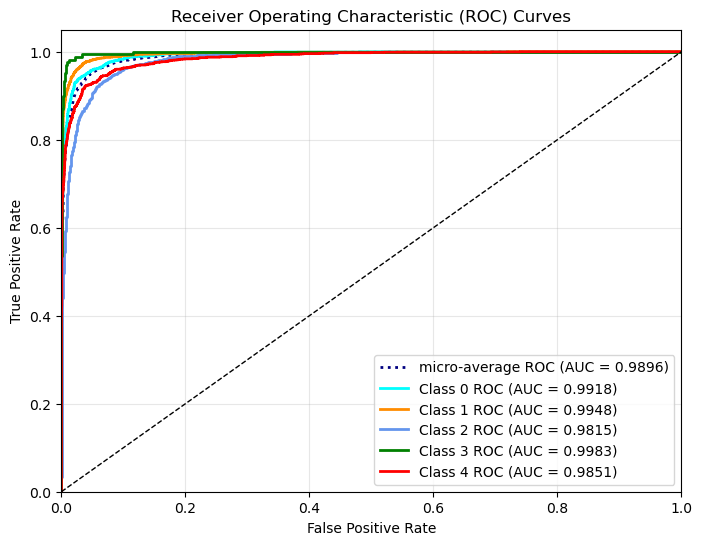

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(one_hot_labels[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 2. Compute micro‐average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(one_hot_labels.ravel(), all_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# 3. Plot all ROC curves
plt.figure(figsize=(8, 6))

# Plot micro-average
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label=f"micro-average ROC (AUC = {roc_auc['micro']:.4f})",
    color="navy",
    linestyle=":",
    linewidth=2
)

# Plot each class's ROC
colors = ["aqua", "darkorange", "cornflowerblue", "green", "red"]
for i, color in zip(range(num_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f"Class {i} ROC (AUC = {roc_auc[i]:.4f})"
    )

# 4. Plot diagonal line for reference
plt.plot([0, 1], [0, 1], "k--", lw=1)

# 5. Format the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
